### Тесты выгрузки данных посредством плагина

In [1]:
import osmnx as ox
from shapely.wkt import loads
from shapely.ops import unary_union

print(ox.__version__)

1.9.4


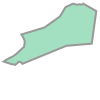

In [2]:
poly_wkt = '''
POLYGON ((93.3838367 56.1794634, 93.3854574 56.180564, 93.3874583 56.1819643, 93.3882308 56.1824838, 93.3894324 56.1833018, 93.3902854 56.1838273, 93.3916318 56.1845557, 93.3924548 56.1850127, 93.3938098 56.185711, 93.3952886 56.1865071, 93.4032726 56.1904872, 93.4044421 56.1911842, 93.4064913 56.1925766, 93.4091306 56.1943615, 93.4114802 56.1962119, 93.4144091 56.1987606, 93.4160077 56.2003363, 93.417424 56.2016553, 93.418 56.20225, 93.4193064 56.2034703, 93.4195804 56.2037262, 93.4199774 56.2041081, 93.4205 56.2045, 93.4207606 56.2047138, 93.4209645 56.2048928, 93.4213132 56.2052061, 93.421753 56.2056179, 93.4227723 56.2066055, 93.4232122 56.2070382, 93.4239095 56.2076946, 93.4252292 56.2090103, 93.4260875 56.2097771, 93.4267902 56.2103588, 93.4270236 56.2105512, 93.427206 56.2106885, 93.4276593 56.211048, 93.4279409 56.2112553, 93.4282547 56.2114656, 93.4284157 56.2116148, 93.4285095 56.2117371, 93.4286758 56.2120921, 93.4287751 56.2123263, 93.4288985 56.2126351, 93.4289226 56.2127261, 93.4289521 56.2128148, 93.4289642 56.2129088, 93.4290031 56.2136956, 93.4290192 56.2140536, 93.4290057 56.2143549, 93.4290057 56.2145756, 93.4290218 56.2147561, 93.4290701 56.2149231, 93.4291238 56.2150604, 93.4291667 56.2152707, 93.4292123 56.2154616, 93.4292981 56.2157852, 93.4293383 56.2159881, 93.4294 56.2166055, 93.4295958 56.2180642, 93.4296387 56.2183326, 93.4298104 56.2190007, 93.4299231 56.2194362, 93.4299874 56.2201401, 93.4300786 56.2210439, 93.4300947 56.222037, 93.4300733 56.2228781, 93.429966 56.224077, 93.4297943 56.2251805, 93.4295583 56.2261974, 93.4293866 56.2269399, 93.4291452 56.22759, 93.4288555 56.2282192, 93.4285015 56.2290124, 93.4281099 56.2298921, 93.4276432 56.2310103, 93.4274983 56.2313949, 93.4272623 56.2319227, 93.4270799 56.2323014, 93.4269351 56.2325936, 93.4267956 56.2328679, 93.4265649 56.2333927, 93.4263611 56.2338101, 93.4260392 56.2343289, 93.4256744 56.2348715, 93.4251702 56.2355602, 93.4244245 56.2366753, 93.4236735 56.2377277, 93.422901 56.2388874, 93.4226865 56.2392272, 93.4738494 56.2546694, 93.507795 56.2790446, 93.5203255 56.2997372, 93.5212415 56.3000271, 93.5219067 56.3002593, 93.522808 56.3006998, 93.5236502 56.301182, 93.5247606 56.3017445, 93.5258013 56.3022475, 93.5270512 56.3027475, 93.5283226 56.3031909, 93.5291702 56.3035332, 93.5299426 56.3040302, 93.5305113 56.3044082, 93.5312086 56.3047266, 93.5323727 56.3051284, 93.5330594 56.3053665, 93.5337031 56.3056373, 93.5340893 56.3059081, 93.5342234 56.3060718, 93.5343897 56.3063485, 93.5346258 56.3065152, 93.5349959 56.3065925, 93.5357416 56.3066997, 93.5367608 56.3068336, 93.5374796 56.3069586, 93.5379571 56.3070657, 93.5383218 56.3070925, 93.5386866 56.3070241, 93.5390997 56.3068604, 93.5399097 56.3064735, 93.5404515 56.3061968, 93.5409021 56.3059051, 93.541283 56.305673, 93.5416317 56.305548, 93.5421628 56.3054379, 93.5437292 56.3052563, 93.5452795 56.3051284, 93.5466957 56.305054, 93.5480153 56.3050927, 93.5486591 56.3051641, 93.5491687 56.3052563, 93.5495254 56.3053724, 93.5498741 56.3055227, 93.5501263 56.3056953, 93.5503757 56.3058188, 93.550609 56.3058634, 93.5507539 56.3058605, 93.5509792 56.3058233, 93.5513949 56.3057578, 93.5518402 56.3057057, 93.5523552 56.3056283, 93.552736 56.3055733, 93.5528406 56.3055517, 93.5529399 56.3055048, 93.5529868 56.3054498, 93.5530901 56.3052727, 93.5531867 56.3051924, 93.5533288 56.3051522, 93.5535675 56.3051492, 93.5538438 56.3051656, 93.5548925 56.3052608, 93.5555631 56.3053382, 93.5561022 56.3053873, 93.5566494 56.3054215, 93.5569552 56.3054423, 93.557104 56.3054542, 93.5573038 56.305484, 93.5577169 56.305612, 93.5582399 56.3058456, 93.5587174 56.3061848, 93.559109 56.3065301, 93.5594523 56.3068991, 93.5595193 56.3070493, 93.5880141 56.2907746, 93.5780092 56.219001, 93.521982 56.2142325, 93.4250011 56.1745513, 93.422701 56.1774577, 93.4225279 56.1776765, 93.4221469 56.1777964, 93.417085 56.1793897, 93.4140376 56.1763777, 93.4140376 56.1760073, 93.4133015 56.1755975, 93.4094225 56.172327, 93.4088846 56.1721852, 93.4045023 56.1736117, 93.4024361 56.173634, 93.4015871 56.1736431, 93.3838367 56.1794634))
'''

poly = loads(poly_wkt)
poly

In [15]:
ox.settings.requests_timeout = 180  # 360

In [3]:
ox.settings.overpass_url

'https://overpass-api.de/api'

In [12]:
# ox.settings.overpass_url = 'https://maps.mail.ru/osm/tools/overpass/api'

In [4]:
retain_all = False

# ox.settings.overpass_url = 'https://overpass.kumi.systems/api'

# ox.settings.overpass_url = 'https://lz4.overpass-api.de/api'
# ox.settings.overpass_url = 'https://maps.mail.ru/osm/tools/overpass/api'
# ox.settings.overpass_url = 'https://overpass.openstreetmap.ru/api'
# ox.settings.overpass_url = 'https://overpass.private.coffee/api'
# ox.settings.overpass_url = 'https://overpass.osm.jp//api'


G = ox.graph_from_polygon(poly, network_type='drive',
                                  simplify=False,
                                  retain_all=retain_all)

In [5]:
G.number_of_edges()

7627

In [ ]:
ox.settings.overpass_url

In [ ]:
G = ox.graph_from_address(
    'Железногорск, Красноярский край, Россия', network_type='drive'
)